# ImpactMeter Final Model
This notebook implements final ImpactMeter logic for judges: formula, rolling last 10 innings, ranking, and visualization.

## Step 1: Load Feature Dataset

In [51]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path(r"D:/VS_CODES/Projects/ImpactMeter")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = DATA_DIR / "features"

print("BASE_DIR:", BASE_DIR)

df = pd.read_csv(BASE_DIR / "data/features/impact_dataset.csv")
OUTPUT_PLAYER_CSV = OUTPUT_DIR / "player_impact_scores.csv"
print('Input shape:', df.shape)
df.head(5)

BASE_DIR: D:\VS_CODES\Projects\ImpactMeter
Input shape: (31609, 15)


,match_id,match_date,season,innings,player,team,strike_rate,phase,pressure_index,batter_impact_score,bowler_impact_score,runs_scored,balls_faced,wickets_taken,economy
0,335982,2008-04-18,2007/08,1,AA Noffke,Royal Challengers Bangalore,NaN,death,0.206054,0.000000,49.958973,NaN,NaN,1.0,10.0
1,335982,2008-04-18,2007/08,1,BB McCullum,Kolkata Knight Riders,216.438356,middle,0.189330,100.000000,0.000000,158.0,73.0,NaN,NaN
2,335982,2008-04-18,2007/08,1,CL White,Royal Challengers Bangalore,NaN,middle,0.216216,0.000000,0.000000,NaN,NaN,0.0,24.0
3,335982,2008-04-18,2007/08,1,DJ Hussey,Kolkata Knight Riders,100.000000,death,0.248649,49.675676,0.000000,12.0,12.0,NaN,NaN
4,335982,2008-04-18,2007/08,1,JH Kallis,Royal Challengers Bangalore,NaN,middle,0.218162,0.000000,43.176919,NaN,NaN,1.0,12.0


## Step 2: Compute Performance Score
Use batting and bowling components; keep formulas close to your hackathon draft.

In [52]:
df['runs_scored'] = pd.to_numeric(df.get('runs_scored', 0), errors='coerce').fillna(0)
df['strike_rate'] = pd.to_numeric(df.get('strike_rate', 0), errors='coerce').fillna(0)
df['batter_impact_score'] = pd.to_numeric(df.get('batter_impact_score', 0), errors='coerce').fillna(0)
df['bowler_impact_score'] = pd.to_numeric(df.get('bowler_impact_score', 0), errors='coerce').fillna(0)
df['wickets_taken'] = pd.to_numeric(df.get('wickets_taken', 0), errors='coerce').fillna(0)

df['performance_score'] = (
    df['runs_scored'] * 0.6
    + df['strike_rate'] * 0.2
    + df['batter_impact_score'] * 0.2
)

df['bowler_performance'] = (
    df['bowler_impact_score'] * 0.7
    + df['wickets_taken'] * 10
)

df[['performance_score', 'bowler_performance']].head(5)

,performance_score,bowler_performance
0,0.000000,44.971281
1,158.087671,0.000000
2,0.000000,0.000000
3,37.135135,0.000000
4,0.000000,40.223843


## Step 3: Context Score
Phase weight plus pressure influence.

In [53]:
phase_weights = {
    'powerplay': 1.1,
    'middle': 1.0,
    'death': 1.4
}

df['pressure_index'] = pd.to_numeric(df.get('pressure_index', 0.5), errors='coerce').fillna(0.5).clip(0, 1)
df['context_score'] = df['phase'].map(phase_weights).fillna(1.0)
df['context_score'] = df['context_score'] * (1 + df['pressure_index'])

df[['phase', 'pressure_index', 'context_score']].head(5)

,phase,pressure_index,context_score
0,death,0.206054,1.688476
1,middle,0.189330,1.189330
2,middle,0.216216,1.216216
3,death,0.248649,1.748108
4,middle,0.218162,1.218162


## Step 4: Raw Impact Score
Blend batter and bowler contributions, then apply context.

In [54]:
df['impact_raw'] = (0.6 * df['performance_score'] + 0.4 * df['bowler_performance']) * df['context_score']
df['impact_raw'].describe()

count    31609.000000
mean        39.139685
std         25.008926
min          0.000000
25%         20.368063
50%         34.395166
75%         52.371751
max        217.775222
Name: impact_raw, dtype: float64

## Step 5: Normalize to 0-100
Min-max normalization for judge-friendly interpretation.

In [55]:
min_val = df['impact_raw'].min()
max_val = df['impact_raw'].max()

if max_val == min_val:
    df['impact_score'] = 50.0
else:
    df['impact_score'] = 100 * (df['impact_raw'] - min_val) / (max_val - min_val)

df['impact_score'] = df['impact_score'].clip(0, 100)
df['impact_score'].describe()

count    31609.000000
mean        17.972515
std         11.483825
min          0.000000
25%          9.352792
50%         15.793884
75%         24.048535
max        100.000000
Name: impact_score, dtype: float64

## Step 6: Rolling Last 10 + Recency Weighting
Aggregate by player-match, compute rolling average, then a recency-weighted rolling ImpactMeter score.

In [56]:
df['match_date'] = pd.to_datetime(df['match_date'], errors='coerce')

player_innings = (
    df.groupby(['player', 'match_id'], as_index=False)
      .agg(
          match_date=('match_date', 'min'),
          impact_score=('impact_score', 'sum')
      )
)

player_innings = player_innings.sort_values(['player', 'match_date', 'match_id'])

player_innings['rolling_IM'] = (
    player_innings
    .groupby('player')['impact_score']
    .rolling(10, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

weights = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

def weighted_recent(scores):
    scores = list(scores)[-10:]
    w = weights[-len(scores):]
    return sum(s * wt for s, wt in zip(scores, w)) / sum(w)

player_innings['weighted_IM'] = (
    player_innings
    .groupby('player')['impact_score']
    .rolling(10, min_periods=1)
    .apply(weighted_recent, raw=False)
    .reset_index(level=0, drop=True)
)

min_val = player_innings['weighted_IM'].min()
max_val = player_innings['weighted_IM'].max()

if max_val == min_val:
    player_innings['IM_score'] = 50.0
else:
    player_innings['IM_score'] = 100 * (
        (player_innings['weighted_IM'] - min_val) / (max_val - min_val)
    )

player_innings['IM_score'] = player_innings['IM_score'].clip(0, 100)
player_innings.head(10)

,player,match_id,match_date,impact_score,rolling_IM,weighted_IM,IM_score
1,A Ashish Reddy,548341,2012-04-26,34.245083,34.245083,34.245083,36.140092
2,A Ashish Reddy,548346,2012-04-29,37.853713,36.049398,36.144362,38.144470
3,A Ashish Reddy,548348,2012-05-01,20.868606,30.989134,30.493709,32.181129
4,A Ashish Reddy,548352,2012-05-04,39.114751,33.020538,32.985596,34.810909
5,A Ashish Reddy,548356,2012-05-06,14.487025,29.313836,28.357459,29.926666
6,A Ashish Reddy,548359,2012-05-08,48.925483,32.582444,32.821867,34.638120
0,A Ashish Reddy,548329,2012-05-10,4.344893,28.548508,27.039557,28.535836
7,A Ashish Reddy,548373,2012-05-18,52.486280,31.540729,31.730029,33.485864
8,A Ashish Reddy,548376,2012-05-20,61.467688,34.865947,37.265048,39.327171
9,A Ashish Reddy,598000,2013-04-05,50.878762,36.467229,40.132849,42.353667


## Step 7: Player Ranking
Rank players by average normalized `IM_score` (0-100).

In [57]:
ranking = (
    player_innings
    .groupby('player')['IM_score']
    .mean()
    .sort_values(ascending=False)
)

ranking.head(20)

player
JPR Scantlebury-Searles    63.511684
DAJ Bracewell              58.407766
A Choudhary                49.618496
C Bosch                    48.652373
DT Patil                   48.180068
AJ Hosein                  48.117822
Umar Gul                   47.339225
RJ Peterson                44.304204
OF Smith                   44.181978
D Pretorius                43.161565
KK Cooper                  42.425161
JE Taylor                  41.866314
PD Collingwood             41.544752
A Flintoff                 41.337277
J Overton                  41.156595
MA Khote                   40.654445
Azhar Mahmood              39.920864
AD Russell                 39.593881
MA Wood                    39.502585
JR Hopes                   38.740976
Name: IM_score, dtype: float64

## Step 8: Save Final Output

In [58]:
OUTPUT_PLAYER_CSV.parent.mkdir(parents=True, exist_ok=True)
player_innings.to_csv(OUTPUT_PLAYER_CSV, index=False)
print('Saved:', OUTPUT_PLAYER_CSV)
print('Rows:', len(player_innings))

Saved: D:\VS_CODES\Projects\ImpactMeter\data\features\player_impact_scores.csv
Rows: 25018


## Step 9: Visualization
Impact trend for a selected player.

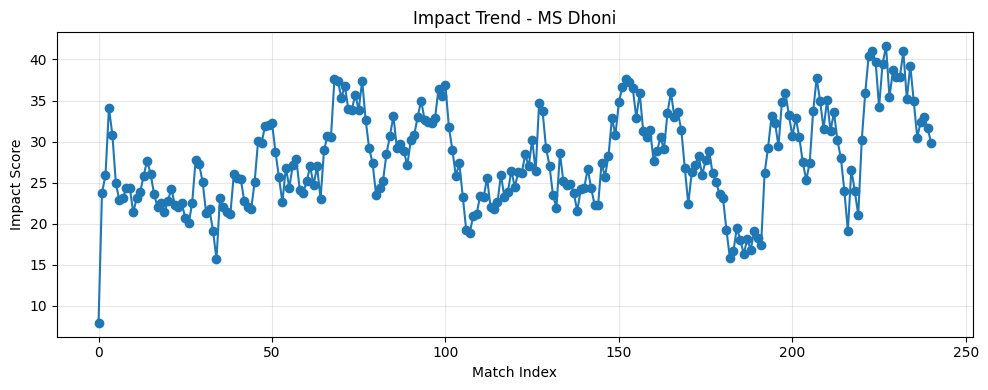

In [59]:
player_query = 'Dhoni'

# Case-insensitive partial match so you can type short names like 'Kohli' or 'Dhoni'.
matches = player_innings[player_innings['player'].str.contains(player_query, case=False, na=False)]['player'].drop_duplicates()

if len(matches) == 0:
    fallback_player = ranking.index[0]
    print(f"No player matched '{player_query}'. Showing '{fallback_player}' instead.")
    player = fallback_player
else:
    player = matches.iloc[0]
    if len(matches) > 1:
        print(f"Multiple matches for '{player_query}'. Using '{player}'.")

plot_df = player_innings[player_innings['player'] == player].copy()
plot_df = plot_df.sort_values(['match_date', 'match_id'])

plt.figure(figsize=(10, 4))
plt.plot(plot_df['IM_score'].values, marker='o', linewidth=1.5)
plt.title('Impact Trend - ' + player)
plt.xlabel('Match Index')
plt.ylabel('Impact Score')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()